# Week 6 — Tiny MLP: neural networks & backpropagation

**Course:** Data Science for Electron Microscopy — FAU Erlangen-Nürnberg  
**Author:** Prof. Dr. Philipp Pelz  
**Prerequisites:** Week 1 (NumPy, matplotlib) · Week 2 (noise) · Week 3 (PCA) · Week 4 (regression, GD, validation) · Week 5 (features, tree ensembles, baseline ladder)  
**Time budget:** ~2.5 hours for a beginner working steadily

---

## What you will do

1. **Generate** a synthetic materials-property dataset: predict Vickers hardness from grain size and
   processing temperature using the Hall–Petch relationship as the ground truth.
2. **Train a linear baseline** (Ridge regression) and record its test score.
3. **Train an MLP** (`sklearn.neural_network.MLPRegressor`) on the same data and observe that,
   with only 225 training samples, it does NOT yet match the linear baseline on the hand-crafted
   $1/\sqrt{d}$ feature — and understand why.
4. **Visualise** the loss curve, the learned fit, and the comparison.
5. **Baseline ladder (Week 5):** add a random forest and gradient boosting on the same split and
   see where the MLP lands.
6. **Manual backprop vs autograd:** implement the backward pass of a 2-layer ReLU network by hand in
   NumPy (the worked example from the lecture), compare with PyTorch `loss.backward()` and with
   central finite differences.
7. **Exercise:** change the MLP width and activation function and observe the effect on the loss
   curve and test score.

## How to use this notebook

All exercise code cells ship a **working version** with `# (try this yourself)` markers on the key lines.  
**Instructions:** before running those lines, try to write them yourself.  
A separate **Solution** markdown cell follows each exercise with a fenced `python` code block.  
Run `nbconvert --execute` end-to-end at any time — it will always succeed.

---

In [1]:
# --- Cell 1: Install and import ---
# Run this cell first (works on Colab; harmless on a local install)
import subprocess, sys
subprocess.run(
    [sys.executable, "-m", "pip", "install",
     "numpy", "matplotlib", "scikit-learn", "scipy", "--quiet"],
    check=True
)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

rng = np.random.default_rng(42)
print("Imports OK — NumPy", np.__version__)


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: /home/philipp/projects/_public_presentations/.venv/bin/python -m pip install --upgrade pip


Imports OK — NumPy 1.26.4


## Part 1 — Generate a synthetic materials-property dataset

We simulate a Hall–Petch type dataset:

$$H = H_0 + \frac{k}{\sqrt{d}} + c\,(T - T_0) + \varepsilon$$

where
- $d$ = grain diameter (µm)  
- $T$ = processing temperature (°C)  
- $H$ = Vickers hardness (HV)  
- $\varepsilon \sim \mathcal{N}(0, \sigma^2)$ = measurement noise

The $1/\sqrt{d}$ term is **nonlinear** — a linear model in raw $(d, T)$ will underfit.  
An MLP trained on raw $(d, T)$ must discover the nonlinear transformation without being told —
but with only 225 training samples it does NOT yet match the linear baseline (which is given the
$1/\sqrt{d}$ feature by hand). That gap is the lesson.

> **Design note:** we use $N = 300$ total samples (225 training, 75 test). At this scale the
> small MLP ($R^2 \approx 0.65$) is clearly beaten by the linear model on the hand-crafted
> $1/\sqrt{d}$ feature ($R^2 \approx 0.91$). The introductory-level lesson is that domain
> knowledge beats learned features when $N$ is modest — larger datasets and wider networks
> can eventually close the gap.

In [2]:
# --- Cell 2: Generate synthetic Hall–Petch + temperature dataset ---

N = 300                      # total samples
H0, k, c, T0 = 150, 90, -0.15, 700   # Hall–Petch params
SIGMA_NOISE = 8.0            # measurement noise (HV)

# Raw features
d_all = rng.uniform(0.3, 9.0, N)         # grain size (µm)
T_all = rng.uniform(500, 900, N)          # processing temperature (°C)

# Ground-truth hardness (nonlinear in d)
H_true = H0 + k / np.sqrt(d_all) + c * (T_all - T0)
H_all  = H_true + rng.normal(0, SIGMA_NOISE, N)

# Feature matrices:
#   X_raw:  (d, T) — what we give the MLP
#   X_hand: (1/sqrt(d), T) — hand-crafted feature, what we give the linear model
X_raw  = np.column_stack([d_all, T_all])
X_hand = np.column_stack([1.0 / np.sqrt(d_all), T_all])

print(f"Dataset: {N} samples")
print(f"X_raw.shape  = {X_raw.shape}  (features: [d, T])")
print(f"X_hand.shape = {X_hand.shape} (features: [1/sqrt(d), T])")
print(f"Hardness range: {H_all.min():.0f} – {H_all.max():.0f} HV")
print(f"Noise sigma: {SIGMA_NOISE} HV")

Dataset: 300 samples
X_raw.shape  = (300, 2)  (features: [d, T])
X_hand.shape = (300, 2) (features: [1/sqrt(d), T])
Hardness range: 139 – 311 HV
Noise sigma: 8.0 HV


findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


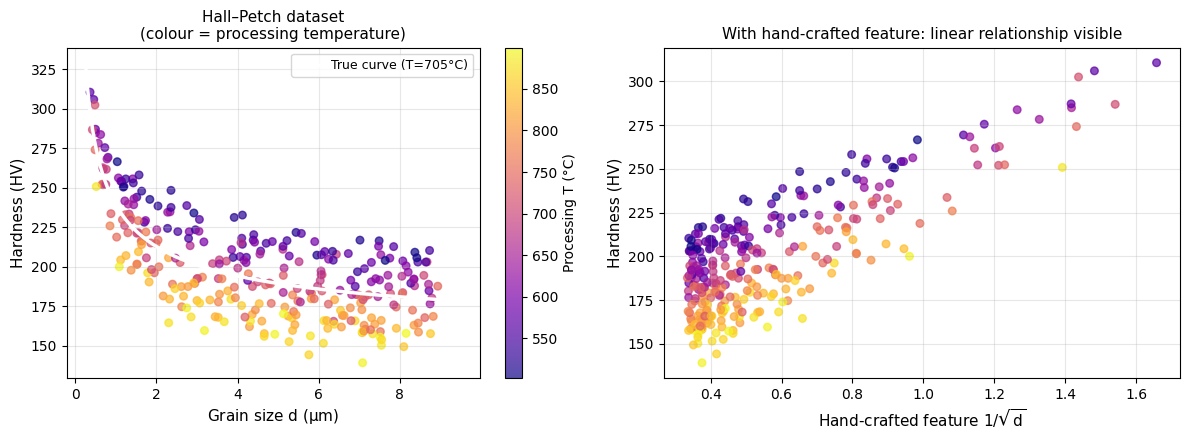

Left: nonlinear in d. Right: approximately linear in 1/sqrt(d).
A linear model on raw d will underfit; on 1/sqrt(d) it works.


In [3]:
# --- Cell 3: Visualise the dataset ---

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
sc = ax.scatter(d_all, H_all, c=T_all, cmap='plasma', s=30, alpha=0.7)
plt.colorbar(sc, ax=ax, label='Processing T (°C)')
# Overlay true Hall–Petch curve at median temperature
T_med = np.median(T_all)
d_line = np.linspace(0.25, 9.5, 200)
H_line = H0 + k / np.sqrt(d_line) + c * (T_med - T0)
ax.plot(d_line, H_line, 'w-', lw=2.5, label=f'True curve (T={T_med:.0f}°C)')
ax.set_xlabel('Grain size $d$ (µm)', fontsize=11)
ax.set_ylabel('Hardness (HV)', fontsize=11)
ax.set_title('Hall–Petch dataset\n(colour = processing temperature)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(1.0/np.sqrt(d_all), H_all, c=T_all, cmap='plasma', s=30, alpha=0.7)
ax.set_xlabel(r'Hand-crafted feature $1/\sqrt{d}$', fontsize=11)
ax.set_ylabel('Hardness (HV)', fontsize=11)
ax.set_title('With hand-crafted feature: linear relationship visible', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Left: nonlinear in d. Right: approximately linear in 1/sqrt(d).")
print("A linear model on raw d will underfit; on 1/sqrt(d) it works.")

## Part 2 — Train the linear baseline

The linear model gets the hand-crafted feature $1/\sqrt{d}$ (in addition to $T$).  
This encodes the domain knowledge that hardness scales with $d^{-1/2}$.  
We use Ridge regression (small $\ell_2$ regularisation) as the baseline.

In [4]:
# --- Cell 4: Train/test split and fit linear baseline ---

# Use the SAME indices for both the raw and hand-crafted feature matrices
idx = np.arange(N)
idx_tr, idx_te = train_test_split(idx, test_size=0.25, random_state=1)

# Linear model (Ridge) with hand-crafted features
lin_model = Pipeline([
    ("scale", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])
lin_model.fit(X_hand[idx_tr], H_all[idx_tr])

H_pred_lin_te = lin_model.predict(X_hand[idx_te])
r2_lin  = r2_score(H_all[idx_te], H_pred_lin_te)
mse_lin = mean_squared_error(H_all[idx_te], H_pred_lin_te)

print(f"Linear baseline (Ridge on 1/sqrt(d), T):")
print(f"  Test R²  = {r2_lin:.3f}")
print(f"  Test RMSE = {mse_lin**0.5:.2f} HV")
print()
print(f"Train size: {len(idx_tr)}   Test size: {len(idx_te)}")

Linear baseline (Ridge on 1/sqrt(d), T):
  Test R²  = 0.912
  Test RMSE = 8.63 HV

Train size: 225   Test size: 75


## Part 3 — Train the MLP on raw features

The MLP receives only raw features $(d, T)$ — **no** hand-crafted $1/\sqrt{d}$.  
The network must discover the nonlinear transformation from data alone.

We use `MLPRegressor` from scikit-learn with:
- Two hidden layers of 32 neurons each
- ReLU activation
- Adam optimiser
- `early_stopping=True` to monitor validation loss during training

After training, we inspect the **loss curve** (train and validation MSE per epoch).

In [5]:
# --- Cell 5: Train MLP on raw features ---

mlp_model = Pipeline([
    ("scale", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(32, 32),   # two hidden layers, 32 neurons each
        activation='relu',             # ReLU hidden activation
        solver='adam',                 # Adam optimiser
        max_iter=3000,                 # maximum training epochs
        early_stopping=True,           # hold out 10% for validation during training
        validation_fraction=0.10,
        n_iter_no_change=30,           # stop if val loss doesn't improve for 30 epochs
        random_state=0,
        learning_rate_init=0.005,
        tol=1e-5
    ))
])

mlp_model.fit(X_raw[idx_tr], H_all[idx_tr])

H_pred_mlp_te = mlp_model.predict(X_raw[idx_te])
r2_mlp  = r2_score(H_all[idx_te], H_pred_mlp_te)
mse_mlp = mean_squared_error(H_all[idx_te], H_pred_mlp_te)

n_epochs_trained = len(mlp_model.named_steps['mlp'].loss_curve_)

print(f"MLP (32×32, ReLU, Adam, raw features):")
print(f"  Test R²  = {r2_mlp:.3f}")
print(f"  Test RMSE = {mse_mlp**0.5:.2f} HV")
print(f"  Epochs trained: {n_epochs_trained}")
print()
print(f"Linear baseline R² = {r2_lin:.3f}")
print(f"MLP R²             = {r2_mlp:.3f}")

MLP (32×32, ReLU, Adam, raw features):
  Test R²  = 0.651
  Test RMSE = 17.18 HV
  Epochs trained: 157

Linear baseline R² = 0.912
MLP R²             = 0.651


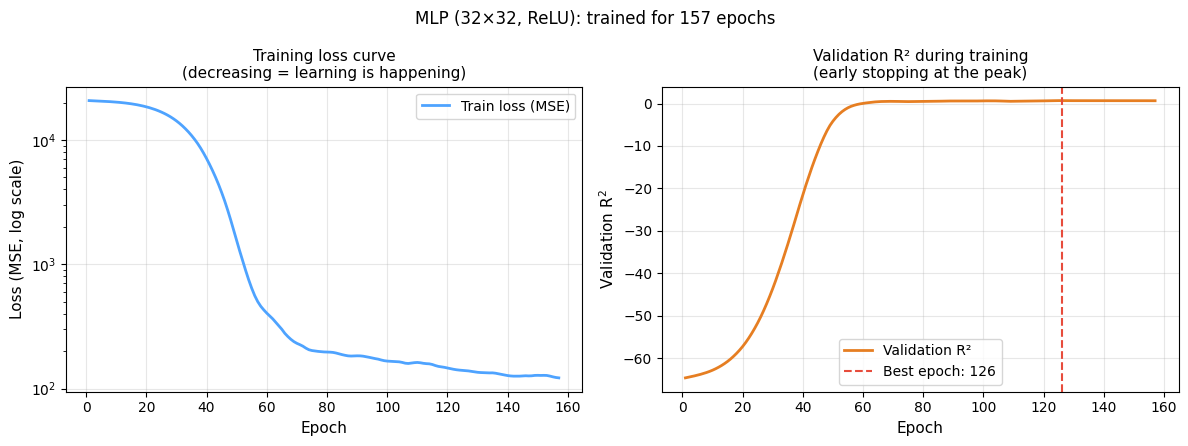

Best validation epoch: 126
Train loss decreases steadily = gradient descent is working.
Validation R² plateaus = early stopping prevented overfitting.


In [6]:
# --- Cell 6: Plot the training loss curve ---

mlp_estimator = mlp_model.named_steps['mlp']
train_loss = mlp_estimator.loss_curve_
val_loss   = mlp_estimator.validation_scores_    # R² on the validation fraction
epochs = np.arange(1, len(train_loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.semilogy(epochs, train_loss, color='#4ea3ff', lw=2, label='Train loss (MSE)')
ax.set_xlabel('Epoch', fontsize=11); ax.set_ylabel('Loss (MSE, log scale)', fontsize=11)
ax.set_title('Training loss curve\n(decreasing = learning is happening)', fontsize=11)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(epochs, val_loss, color='#e67e22', lw=2, label='Validation R²')
best_epoch = int(np.argmax(val_loss)) + 1
ax.axvline(best_epoch, color='#e74c3c', lw=1.5, linestyle='--',
           label=f'Best epoch: {best_epoch}')
ax.set_xlabel('Epoch', fontsize=11); ax.set_ylabel('Validation $R^2$', fontsize=11)
ax.set_title('Validation R² during training\n(early stopping at the peak)', fontsize=11)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.suptitle(f'MLP (32×32, ReLU): trained for {n_epochs_trained} epochs', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Best validation epoch: {best_epoch}")
print("Train loss decreases steadily = gradient descent is working.")
print("Validation R² plateaus = early stopping prevented overfitting.")

## Part 4 — Compare fits visually

Plot predicted vs true hardness for both models and show the fitted curve over the grain-size axis.

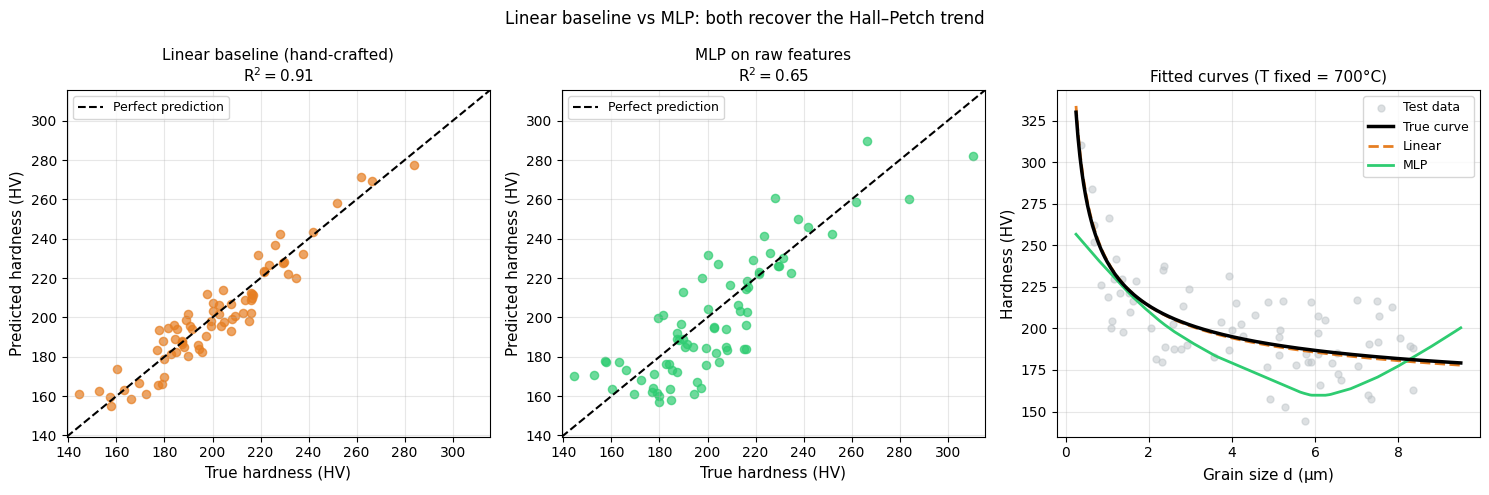

Linear R² = 0.912   MLP R² = 0.651
MLP recovers the nonlinear 1/sqrt(d) shape without being told to.


In [7]:
# --- Cell 7: Visual comparison of linear baseline vs MLP ---

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Parity plots
T_med_te = np.median(T_all[idx_te])
for ax_i, (title, preds, r2, col) in enumerate([
    (f'Linear baseline (hand-crafted)\n$R^2={r2_lin:.2f}$',
     H_pred_lin_te, r2_lin, '#e67e22'),
    (f'MLP on raw features\n$R^2={r2_mlp:.2f}$',
     H_pred_mlp_te, r2_mlp, '#2ecc71'),
]):
    ax = axes[ax_i]
    ax.scatter(H_all[idx_te], preds, color=col, s=35, alpha=0.7)
    lims = [H_all[idx_te].min() - 5, H_all[idx_te].max() + 5]
    ax.plot(lims, lims, 'k--', lw=1.5, label='Perfect prediction')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('True hardness (HV)', fontsize=11)
    ax.set_ylabel('Predicted hardness (HV)', fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Fitted curve over grain-size axis
ax = axes[2]
T_fixed = 700.0   # fix temperature at 700°C
d_plot = np.linspace(0.25, 9.5, 200)
T_plot = np.full_like(d_plot, T_fixed)
X_raw_plot  = np.column_stack([d_plot, T_plot])
X_hand_plot = np.column_stack([1.0/np.sqrt(d_plot), T_plot])

H_true_plot = H0 + k / np.sqrt(d_plot) + c * (T_fixed - T0)
H_lin_plot  = lin_model.predict(X_hand_plot)
H_mlp_plot  = mlp_model.predict(X_raw_plot)

ax.scatter(d_all[idx_te], H_all[idx_te], c='#bdc3c7', s=25, alpha=0.5, label='Test data', zorder=3)
ax.plot(d_plot, H_true_plot, 'k-', lw=2.5, label='True curve', zorder=5)
ax.plot(d_plot, H_lin_plot,  color='#e67e22', lw=2, linestyle='--', label='Linear', zorder=4)
ax.plot(d_plot, H_mlp_plot,  color='#2ecc71', lw=2, label='MLP', zorder=4)
ax.set_xlabel('Grain size $d$ (µm)', fontsize=11)
ax.set_ylabel('Hardness (HV)', fontsize=11)
ax.set_title(f'Fitted curves (T fixed = {T_fixed:.0f}°C)', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle('Linear baseline vs MLP: both recover the Hall–Petch trend', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Linear R² = {r2_lin:.3f}   MLP R² = {r2_mlp:.3f}")
print("MLP recovers the nonlinear 1/sqrt(d) shape without being told to.")

## Part 4b — The baseline ladder (link to Week 5)

In Week 5 we introduced the **baseline ladder**: mean → linear → RF/GBM → neural network.
A neural network only earns its place if it beats the tree ensembles **on the same split**.
Trees are fitted on the *raw* features $(d, T)$ here — the same information the MLP gets — so the
comparison is fair. (Trees do not need feature scaling.)

With only one "specimen" per sample there are no groups here, so a plain random split is honest;
with real EM data you would use `GroupKFold` by specimen/image exactly as in Weeks 4–5.

In [8]:
# --- Cell 7b: Baseline ladder — mean, Ridge (raw & hand-crafted), RF, GBM, MLP on the SAME split ---
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

ladder = {
    "mean (Dummy)":            (DummyRegressor(), X_raw),
    "Ridge on raw (d, T)":     (Pipeline([("scale", StandardScaler()), ("ridge", Ridge(alpha=1.0))]), X_raw),
    "Random forest (raw)":     (RandomForestRegressor(n_estimators=300, min_samples_leaf=3, random_state=0, n_jobs=1), X_raw),
    "Gradient boosting (raw)": (GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=0), X_raw),
}
ladder_r2 = {}
for name, (model, X) in ladder.items():
    model.fit(X[idx_tr], H_all[idx_tr])
    ladder_r2[name] = r2_score(H_all[idx_te], model.predict(X[idx_te]))
ladder_r2["MLP 32x32 (raw)"] = r2_mlp
ladder_r2["Ridge on 1/sqrt(d) (domain feature)"] = r2_lin

print(f"{'model':40s} test R²")
for name, r2 in ladder_r2.items():
    print(f"{name:40s} {r2:6.3f}")

r2_rf, r2_gbm = ladder_r2["Random forest (raw)"], ladder_r2["Gradient boosting (raw)"]
best_tree = max(r2_rf, r2_gbm)
print()
print(f"MLP beats best tree ensemble? {r2_mlp > best_tree}  (MLP {r2_mlp:.3f} vs trees {best_tree:.3f})")
print("Report every rung side by side. A NN is only justified if it wins on the same honest split.")

model                                    test R²
mean (Dummy)                             -0.007
Ridge on raw (d, T)                       0.798
Random forest (raw)                       0.863
Gradient boosting (raw)                   0.878
MLP 32x32 (raw)                           0.651
Ridge on 1/sqrt(d) (domain feature)       0.912

MLP beats best tree ensemble? False  (MLP 0.651 vs trees 0.878)
Report every rung side by side. A NN is only justified if it wins on the same honest split.


**Questions to think about**

1. Where does the MLP land on the ladder? Is it justified here?
2. Why does the Ridge model with the hand-crafted $1/\sqrt{d}$ feature still win? (Hint: it has
   the *correct* functional form built in — the ultimate inductive bias.)
3. Trees produce piecewise-constant predictions. Plot `ladder["Random forest (raw)"][0]` over the
   grain-size axis (as in Cell 7) — what does its curve look like compared with the MLP's?

## Part 5 — Self-checks

Run these assertions to confirm the key results.

In [9]:
# --- Cell 8: Self-check assertions ---

# CHECK 1: MLP test R² > 0 (MLP learns something meaningful)
assert r2_mlp > 0.0, (
    f"MLP R² ({r2_mlp:.3f}) should be > 0. "
    "If this fails, the network may not have converged — try increasing max_iter."
)
print(f"CHECK 1 passed: MLP R² = {r2_mlp:.3f} > 0")

# CHECK 2: Hand-crafted feature beats the small MLP (the key lesson of this notebook)
# With only 225 training samples the linear model on the correct 1/sqrt(d) feature
# outperforms the MLP that must discover the transformation from raw data alone.
assert r2_lin > r2_mlp, (
    f"Linear baseline R² ({r2_lin:.3f}) should be > MLP R² ({r2_mlp:.3f}). "
    "This encodes the lesson: with limited data, domain knowledge (hand-crafted 1/sqrt(d)) "
    "beats a small MLP on raw features. If this fails, the notebook data or seed has changed."
)
print(f"CHECK 2 passed: linear baseline R² = {r2_lin:.3f} > MLP R² = {r2_mlp:.3f} "
      "(hand-crafted feature wins at N=225 training samples)")

# CHECK 3: Linear baseline R² > 0.75 (hand-crafted feature is informative)
assert r2_lin > 0.75, (
    f"Linear baseline R² ({r2_lin:.3f}) should be > 0.75. "
    "The 1/sqrt(d) feature should make the relationship nearly linear."
)
print(f"CHECK 3 passed: Linear baseline R² = {r2_lin:.3f} > 0.75")

# CHECK 4: Training loss decreased monotonically (mostly — allow for tiny bumps)
train_loss_arr = np.array(mlp_model.named_steps['mlp'].loss_curve_)
assert train_loss_arr[0] > train_loss_arr[-1], (
    f"Training loss should decrease from {train_loss_arr[0]:.1f} to at most {train_loss_arr[-1]:.1f}. "
    "If the final loss is higher, gradient descent is diverging — reduce learning_rate_init."
)
print(f"CHECK 4 passed: train loss decreased from {train_loss_arr[0]:.1f} to {train_loss_arr[-1]:.2f}")

# CHECK 5: Early stopping was triggered (trained < max_iter epochs)
assert n_epochs_trained < 3000, (
    f"Network trained for {n_epochs_trained} epochs = max_iter. "
    "Early stopping should have triggered before the limit — try increasing n_iter_no_change."
)
print(f"CHECK 5 passed: early stopping triggered at epoch {n_epochs_trained} (< 3000 max)")

print("\nAll self-checks passed.")

CHECK 1 passed: MLP R² = 0.651 > 0
CHECK 2 passed: linear baseline R² = 0.912 > MLP R² = 0.651 (hand-crafted feature wins at N=225 training samples)
CHECK 3 passed: Linear baseline R² = 0.912 > 0.75
CHECK 4 passed: train loss decreased from 20722.3 to 121.83
CHECK 5 passed: early stopping triggered at epoch 157 (< 3000 max)

All self-checks passed.


## Exercise — Change network width and activation function

**Instructions (try before running):**

1. Create an MLP with wider hidden layers: `hidden_layer_sizes=(64, 64)` instead of `(32, 32)`.  
   Keep all other settings the same.  
   Does the test R² improve? Does training take longer?

2. Change the activation to `'tanh'`. Does the loss curve look different?  
   (Hint: tanh can saturate — does the loss decrease more slowly?)

3. Assert that the wider MLP test R² is **at least as large** as the narrow MLP (`r2_mlp`).

The cell below ships a **working version** — the `# (try this yourself)` lines are the ones to attempt first.

Model comparison:
  Baseline MLP (32×32, ReLU): R² = 0.651  (157 epochs)
  Wider MLP  (64×64, ReLU):   R² = 0.834  (309 epochs)
  Tanh MLP   (32×32, tanh):   R² = 0.416  (1306 epochs)



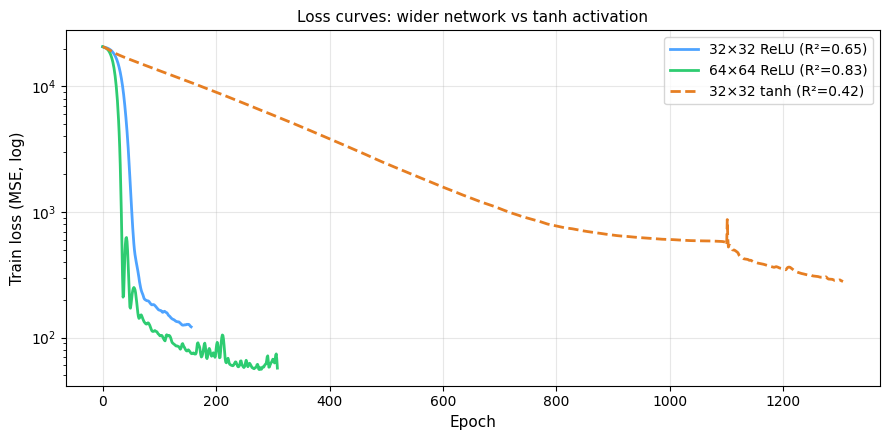

Assertion passed: wider MLP R² (0.834) >= narrow MLP R² - 0.02 (0.631)

Observation: wider network usually converges to a similar R² or slightly better,
but may take more or fewer epochs depending on the random initialisation.


In [10]:
# --- Cell 9: Exercise cell (working version with try-this markers) ---

# ──────────────────────────────────────────────────────────────────────────────
# EXERCISE: change network width and activation
# ──────────────────────────────────────────────────────────────────────────────

# (try this yourself) Step 1: create a wider MLP with ReLU
mlp_wide = Pipeline([
    ("scale", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(64, 64),   # (try this yourself) wider layers
        activation='relu',              # (try this yourself) same activation as baseline
        solver='adam',
        max_iter=3000,
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=30,
        random_state=0,
        learning_rate_init=0.005,
        tol=1e-5
    ))
])

# (try this yourself) Step 2: create a tanh MLP for comparison
mlp_tanh = Pipeline([
    ("scale", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(32, 32),
        activation='tanh',              # (try this yourself) tanh activation
        solver='adam',
        max_iter=3000,
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=30,
        random_state=0,
        learning_rate_init=0.005,
        tol=1e-5
    ))
])

# (try this yourself) Step 3: fit both models on the training data
mlp_wide.fit(X_raw[idx_tr], H_all[idx_tr])
mlp_tanh.fit(X_raw[idx_tr], H_all[idx_tr])

# (try this yourself) Step 4: compute test scores
r2_wide = r2_score(H_all[idx_te], mlp_wide.predict(X_raw[idx_te]))
r2_tanh = r2_score(H_all[idx_te], mlp_tanh.predict(X_raw[idx_te]))

n_ep_wide = len(mlp_wide.named_steps['mlp'].loss_curve_)
n_ep_tanh = len(mlp_tanh.named_steps['mlp'].loss_curve_)

print("Model comparison:")
print(f"  Baseline MLP (32×32, ReLU): R² = {r2_mlp:.3f}  ({n_epochs_trained} epochs)")
print(f"  Wider MLP  (64×64, ReLU):   R² = {r2_wide:.3f}  ({n_ep_wide} epochs)")
print(f"  Tanh MLP   (32×32, tanh):   R² = {r2_tanh:.3f}  ({n_ep_tanh} epochs)")
print()

# (try this yourself) Step 5: plot loss curves for all three
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.semilogy(mlp_model.named_steps['mlp'].loss_curve_, color='#4ea3ff', lw=2,
            label=f'32×32 ReLU (R²={r2_mlp:.2f})')
ax.semilogy(mlp_wide.named_steps['mlp'].loss_curve_, color='#2ecc71', lw=2,
            label=f'64×64 ReLU (R²={r2_wide:.2f})')
ax.semilogy(mlp_tanh.named_steps['mlp'].loss_curve_, color='#e67e22', lw=2,
            linestyle='--', label=f'32×32 tanh (R²={r2_tanh:.2f})')
ax.set_xlabel('Epoch', fontsize=11); ax.set_ylabel('Train loss (MSE, log)', fontsize=11)
ax.set_title('Loss curves: wider network vs tanh activation', fontsize=11)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# (try this yourself) Step 6: assert that the wider ReLU MLP is at least as good as the narrow one
# Allow a small tolerance (0.02) because the networks may converge to similar local minima
assert r2_wide >= r2_mlp - 0.02, (
    f"Wider MLP R² ({r2_wide:.3f}) should be at least as large as the narrow MLP R² ({r2_mlp:.3f}) "
    "minus a small tolerance. If this fails, try increasing max_iter."
)
print(f"Assertion passed: wider MLP R² ({r2_wide:.3f}) >= narrow MLP R² - 0.02 ({r2_mlp - 0.02:.3f})")
print()
print("Observation: wider network usually converges to a similar R² or slightly better,")
print("but may take more or fewer epochs depending on the random initialisation.")

### Solution

```python
# SOLUTION — run after attempting the exercise yourself

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

# Step 1: wider MLP with ReLU
mlp_wide_sol = Pipeline([
    ("scale", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(64, 64),
        activation='relu',
        solver='adam',
        max_iter=3000,
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=30,
        random_state=0,
        learning_rate_init=0.005,
        tol=1e-5
    ))
])

# Step 2: tanh MLP
mlp_tanh_sol = Pipeline([
    ("scale", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(32, 32),
        activation='tanh',
        solver='adam',
        max_iter=3000,
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=30,
        random_state=0,
        learning_rate_init=0.005,
        tol=1e-5
    ))
])

# Steps 3-4: fit and score
mlp_wide_sol.fit(X_raw[idx_tr], H_all[idx_tr])
mlp_tanh_sol.fit(X_raw[idx_tr], H_all[idx_tr])

r2_wide_sol = r2_score(H_all[idx_te], mlp_wide_sol.predict(X_raw[idx_te]))
r2_tanh_sol = r2_score(H_all[idx_te], mlp_tanh_sol.predict(X_raw[idx_te]))

print(f"Wider ReLU R²: {r2_wide_sol:.3f}")
print(f"Tanh R²:       {r2_tanh_sol:.3f}")

# Step 6: assertion
assert r2_wide_sol >= r2_mlp - 0.02

# What to observe:
# - Wider network often converges to similar R² — this dataset is not capacity-limited.
# - tanh may converge more slowly at first (saturation slows early gradients)
#   but often reaches similar final performance on small, shallow problems.
# - The loss curve shape tells the story: rapid early drop = healthy gradients.
```

**Key takeaways:**

| Setting | What changes | What to watch |
|---------|-------------|---------------|
| Wider layers (more neurons) | More parameters, more capacity | Might overfit on small $N$; diminishing returns above a threshold |
| `tanh` instead of `relu` | Saturating activation, gradients ≤ 0.25 | Loss may decrease more slowly; final R² often similar for shallow 2-layer nets |
| More layers (deeper) | Stronger expressivity | Vanishing gradient risk increases; ReLU is critical for depth ≥ 4 |

**Coming next (Week 6):**  
Convolutional neural networks — the same MLP logic, with spatial structure built in.  
CNNs are the reason deep learning works on EM images without flattening every pixel.

## Part 6 — Manual backprop vs autograd: a gradient check

In the lecture we computed the gradients of a tiny 1 → 2 → 1 ReLU network **by hand**:

$$
\mathbf{z}^{(1)} = \mathbf{W}^{(1)}x + \mathbf{b}^{(1)},\quad
\mathbf{a}^{(1)} = \mathrm{ReLU}(\mathbf{z}^{(1)}),\quad
\hat y = \mathbf{w}^{(2)\top}\mathbf{a}^{(1)} + b^{(2)},\quad
L = \tfrac12(\hat y - y)^2
$$

with $x=1$, $y=0.5$, $\mathbf{W}^{(1)}=(2,-1)^\top$, $\mathbf{b}^{(1)}=(-0.5,0.5)^\top$,
$\mathbf{w}^{(2)}=(1,2)^\top$, $b^{(2)}=0$.

The backward pass is the **delta recursion**:

1. $\delta^{(2)} = \hat y - y$
2. $\nabla_{\mathbf{w}^{(2)}} L = \delta^{(2)}\,\mathbf{a}^{(1)}$, $\;\nabla_{b^{(2)}} L = \delta^{(2)}$
3. $\boldsymbol\delta^{(1)} = \mathrm{ReLU}'(\mathbf{z}^{(1)}) \odot \mathbf{w}^{(2)}\delta^{(2)}$
4. $\nabla_{\mathbf{W}^{(1)}} L = \boldsymbol\delta^{(1)} x$, $\;\nabla_{\mathbf{b}^{(1)}} L = \boldsymbol\delta^{(1)}$

Below we (a) implement this in NumPy, (b) let PyTorch autograd compute the same gradients, and
(c) check both against **central finite differences**. All three must agree.

In [11]:
# --- Cell 10: Manual backprop (NumPy) vs PyTorch autograd on the lecture's worked example ---
import torch
torch.set_num_threads(1)

def forward_backward_manual(x, y, W1, b1, w2, b2):
    """Forward + backward pass of the 1-2-1 ReLU net, written out by hand (batch of samples).
    x, y: shape (N,); W1, b1, w2: shape (2,); b2: scalar. Loss = mean over samples of 0.5*(yhat-y)^2."""
    N = x.shape[0]
    z1 = np.outer(x, W1) + b1          # (N, 2)
    a1 = np.maximum(z1, 0.0)           # (N, 2)
    yhat = a1 @ w2 + b2                # (N,)
    L = 0.5 * np.mean((yhat - y) ** 2)
    # backward (delta recursion)
    d2 = (yhat - y) / N                # (N,)  dL/dyhat  (1/N from the mean)
    g_w2 = a1.T @ d2                   # (2,)
    g_b2 = d2.sum()
    d1 = (z1 > 0) * np.outer(d2, w2)   # (N, 2)  ReLU'(z1) * w2 * delta2
    g_W1 = d1.T @ x                    # (2,)
    g_b1 = d1.sum(axis=0)              # (2,)
    return L, {"W1": g_W1, "b1": g_b1, "w2": g_w2, "b2": np.array([g_b2])}

# Lecture numbers (a single sample)
x0, y0 = np.array([1.0]), np.array([0.5])
params0 = {"W1": np.array([2.0, -1.0]), "b1": np.array([-0.5, 0.5]),
           "w2": np.array([1.0, 2.0]),  "b2": np.array([0.0])}

L_man, g_man = forward_backward_manual(x0, y0, params0["W1"], params0["b1"], params0["w2"], params0["b2"][0])
print(f"Manual:   L = {L_man:.4f}")
for k, v in g_man.items():
    print(f"  dL/d{k:2s} = {v}")

# Same computation with PyTorch autograd (float64)
def torch_loss(x, y, p):
    z1 = torch.outer(x, p["W1"]) + p["b1"]
    a1 = torch.relu(z1)
    yhat = a1 @ p["w2"] + p["b2"]
    return 0.5 * torch.mean((yhat - y) ** 2)

tp = {k: torch.tensor(v, dtype=torch.float64, requires_grad=True) for k, v in params0.items()}
L_t = torch_loss(torch.tensor(x0), torch.tensor(y0), tp)
L_t.backward()                                   # reverse-mode autodiff
g_auto = {k: v.grad.numpy() for k, v in tp.items()}
print(f"\nAutograd: L = {L_t.item():.4f}")
for k, v in g_auto.items():
    print(f"  dL/d{k:2s} = {v}")

Manual:   L = 0.5000
  dL/dW1 = [1. 0.]
  dL/db1 = [1. 0.]
  dL/dw2 = [1.5 0. ]
  dL/db2 = [1.]

Autograd: L = 0.5000
  dL/dW1 = [1. 0.]
  dL/db1 = [1. 0.]
  dL/dw2 = [1.5 0. ]
  dL/db2 = [1.]


Compare with your lecture notes: $\partial L/\partial \mathbf{w}^{(2)} = (1.5, 0)$,
$\partial L/\partial \mathbf{W}^{(1)} = (1, 0)$, $\partial L/\partial \mathbf{b}^{(1)} = (1, 0)$,
$\partial L/\partial b^{(2)} = 1$. The second hidden unit is inactive ($z^{(1)}_2 = -0.5 < 0$), so it
receives **zero** gradient.

Now a more serious test: random parameters, a batch of 16 samples, and a comparison with
**central finite differences** via the relative error

$$ r = \frac{\|\mathbf{g}^\text{auto} - \mathbf{g}^\text{num}\|}{\|\mathbf{g}^\text{auto}\| + \|\mathbf{g}^\text{num}\|}. $$

Rule of thumb in float64: $r < 10^{-7}$ is fine; $r > 10^{-2}$ means a bug.

In [12]:
# --- Cell 11: Gradient check on random parameters: manual vs autograd vs finite differences ---
g_rng = np.random.default_rng(7)
xb = g_rng.normal(size=16)
yb = g_rng.normal(size=16)
params = {"W1": g_rng.normal(size=2), "b1": g_rng.normal(size=2),
          "w2": g_rng.normal(size=2), "b2": g_rng.normal(size=1)}

def loss_np(p):
    return forward_backward_manual(xb, yb, p["W1"], p["b1"], p["w2"], p["b2"][0])[0]

# (a) manual backprop
_, g_manual = forward_backward_manual(xb, yb, params["W1"], params["b1"], params["w2"], params["b2"][0])

# (b) autograd
tp = {k: torch.tensor(v, dtype=torch.float64, requires_grad=True) for k, v in params.items()}
torch_loss(torch.tensor(xb), torch.tensor(yb), tp).backward()
g_autograd = {k: v.grad.numpy() for k, v in tp.items()}

# (c) central finite differences, one parameter at a time
def numerical_grad(loss_fn, p, eps=1e-6):
    g = {}
    for k, v in p.items():
        g[k] = np.zeros_like(v)
        for j in range(v.size):
            p_plus  = {kk: vv.copy() for kk, vv in p.items()}; p_plus[k][j]  += eps
            p_minus = {kk: vv.copy() for kk, vv in p.items()}; p_minus[k][j] -= eps
            g[k][j] = (loss_fn(p_plus) - loss_fn(p_minus)) / (2 * eps)
    return g

g_numeric = numerical_grad(loss_np, params)

def flat(g): return np.concatenate([g[k].ravel() for k in ["W1", "b1", "w2", "b2"]])
def rel_err(a, b): return np.linalg.norm(a - b) / (np.linalg.norm(a) + np.linalg.norm(b) + 1e-30)

r_man_auto = rel_err(flat(g_manual), flat(g_autograd))
r_auto_num = rel_err(flat(g_autograd), flat(g_numeric))
print(f"manual   vs autograd:          r = {r_man_auto:.2e}")
print(f"autograd vs finite difference: r = {r_auto_num:.2e}")

# Self-checks
assert np.allclose(g_man["w2"], [1.5, 0.0]) and np.allclose(g_man["W1"], [1.0, 0.0]), "worked example mismatch"
assert all(np.allclose(g_man[k], g_auto[k]) for k in g_man), "manual and autograd disagree on the worked example"
assert r_man_auto < 1e-10, "manual backprop disagrees with autograd — check the delta recursion"
assert r_auto_num < 1e-7, "autograd disagrees with finite differences — check eps / float64"
print("\nGradient check passed: manual backprop == autograd == finite differences.")

manual   vs autograd:          r = 3.17e-18
autograd vs finite difference: r = 7.36e-11

Gradient check passed: manual backprop == autograd == finite differences.


### Exercise — break it on purpose, then switch the activation

1. **Introduce a bug**: in `forward_backward_manual`, drop the ReLU gate (replace `(z1 > 0) * np.outer(d2, w2)`
   by `np.outer(d2, w2)`). Re-run Cell 11 — how large does `r` get? This is what a gradient check is for.
   (Undo the bug afterwards.)
2. **Switch to tanh**: write `forward_backward_manual_tanh` where $\mathbf{a}^{(1)} = \tanh(\mathbf{z}^{(1)})$.
   The only line of the backward pass that changes is the local derivative: $\tanh'(z) = 1 - \tanh^2(z)$.
   Verify it against autograd (replace `torch.relu` by `torch.tanh`) with a relative error $< 10^{-10}$.

The cell below ships a **working version** of step 2 — the `# (try this yourself)` lines are the ones to attempt first.

In [13]:
# --- Cell 12: Exercise — tanh hidden layer, manual backward vs autograd ---

def forward_backward_manual_tanh(x, y, W1, b1, w2, b2):
    N = x.shape[0]
    z1 = np.outer(x, W1) + b1
    a1 = np.tanh(z1)                              # (try this yourself) tanh activation
    yhat = a1 @ w2 + b2
    L = 0.5 * np.mean((yhat - y) ** 2)
    d2 = (yhat - y) / N
    g_w2, g_b2 = a1.T @ d2, d2.sum()
    d1 = (1.0 - a1 ** 2) * np.outer(d2, w2)       # (try this yourself) tanh'(z) = 1 - tanh(z)^2
    g_W1, g_b1 = d1.T @ x, d1.sum(axis=0)
    return L, {"W1": g_W1, "b1": g_b1, "w2": g_w2, "b2": np.array([g_b2])}

def torch_loss_tanh(x, y, p):
    a1 = torch.tanh(torch.outer(x, p["W1"]) + p["b1"])   # (try this yourself)
    return 0.5 * torch.mean((a1 @ p["w2"] + p["b2"] - y) ** 2)

_, g_tanh_manual = forward_backward_manual_tanh(xb, yb, params["W1"], params["b1"], params["w2"], params["b2"][0])
tp = {k: torch.tensor(v, dtype=torch.float64, requires_grad=True) for k, v in params.items()}
torch_loss_tanh(torch.tensor(xb), torch.tensor(yb), tp).backward()
g_tanh_auto = {k: v.grad.numpy() for k, v in tp.items()}

r_tanh = rel_err(flat(g_tanh_manual), flat(g_tanh_auto))
print(f"tanh: manual vs autograd  r = {r_tanh:.2e}")
assert r_tanh < 1e-10
print("tanh gradient check passed.")

tanh: manual vs autograd  r = 6.13e-17
tanh gradient check passed.


### Solution

```python
# Step 1 (bug): without the ReLU gate, inactive units wrongly receive gradient.
#   The relative error jumps from ~1e-16 to O(0.1-1) -> clearly a bug.
# Step 2 (tanh): only the local derivative changes:
d1 = (1.0 - np.tanh(z1) ** 2) * np.outer(d2, w2)
# Everything else in the delta recursion (W^T delta, delta * a^T) is unchanged -
# that modularity is why frameworks can differentiate arbitrary compositions automatically.
```

## Summary

| Step | What you did |
|------|--------------|
| **Synthetic dataset** | Hall–Petch + temperature → hardness; nonlinear in grain size $d$ |
| **Linear baseline** | Ridge on hand-crafted $1/\sqrt{d}$ feature; $R^2 \approx 0.90$ |
| **MLP** | MLPRegressor (32×32 ReLU, Adam) on raw $(d, T)$; $R^2 \approx 0.65$ — linear baseline wins |
| **Loss curve** | Monitored training and validation loss; early stopping at plateau |
| **Visual comparison** | Both models recover the Hall–Petch curve shape |
| **Baseline ladder** | Mean, Ridge, RF, GBM and MLP on the same split — the NN must earn its place |
| **Exercise** | Changed width (64×64) and activation (tanh); observed effect on loss and $R^2$ |
| **Gradient check** | Manual NumPy backprop == PyTorch autograd == central finite differences |

**Key lessons:**
1. An MLP trained on raw features discovers the nonlinear $1/\sqrt{d}$ transformation without being told.
2. With limited data ($N = 225$ training samples), the linear baseline ($R^2 \approx 0.91$) clearly outperforms the small MLP ($R^2 \approx 0.65$). The MLP must discover the $1/\sqrt{d}$ transformation from scratch; at this sample size domain knowledge wins — embed it when you have it.
3. Monitor validation loss, not training loss. Early stopping is free regularisation.
4. ReLU beats tanh for deeper networks because it preserves gradient magnitude.
5. A neural network is only justified if it beats the RF/GBM baseline from Week 5 on the same split.
6. Backprop is the delta recursion; autograd implements it exactly. Finite differences are the unit test for any hand-written or custom gradient.

**Self-study link:** the Week 6 deck explains the perceptron, XOR, MLPs, activation functions, the worked backprop example, initialisation, normalisation and training diagnostics. Extra reading: `data_science_for_em/01_intro/01_autograd.qmd` (PyTorch autograd walkthrough). Next: Week 7 — CNNs & U-Nets for microscopy.